In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import dask
import scipy.stats as stats
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
spkws = dict(projection = ccrs.PlateCarree(), transform = ccrs.PlateCarree())

from siphon.catalog import TDSCatalog
from xclim.core.calendar import convert_calendar, percentile_doy
import xclim.indicators as xci

# pysal.esda for spatial autocorrelation analysis
import esda 
import libpysal as lps

/Users/lilianchanty/opt/anaconda3/envs/UTCDW/lib/python3.9/site-packages/xclim/indices/fire/_cffwis.py:207: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  def _day_length(lat: int | float, mth: int):  # pragma: no cover
/Users/lilianchanty/opt/anaconda3/envs/UTCDW/lib/python3.9/site-packages/xclim/indices/fire/_cffwis.py:227: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for de

## Suitability for disease transmission

In [2]:
# Load the csv file containing suitability at each temperature
suitability = pd.read_csv("data-processed/S.output.lowerCI.csv") 
suitability = suitability[["temp", "scaled_lowerCI"]]
suitability

,temp,scaled_lowerCI
0,0.0,0.0
1,0.1,0.0
2,0.2,0.0
3,0.3,0.0
4,0.4,0.0
...,...,...
446,44.6,0.0
447,44.7,0.0
448,44.8,0.0
449,44.9,0.0


In [3]:
# Create an interpolation function such that the suitability of any temperature can be calculated (even if it is not in the csv file)

from scipy.interpolate import interp1d
suit_func = interp1d(suitability["temp"], suitability["scaled_lowerCI"], 
                     bounds_error=False, fill_value=0)
suit_func

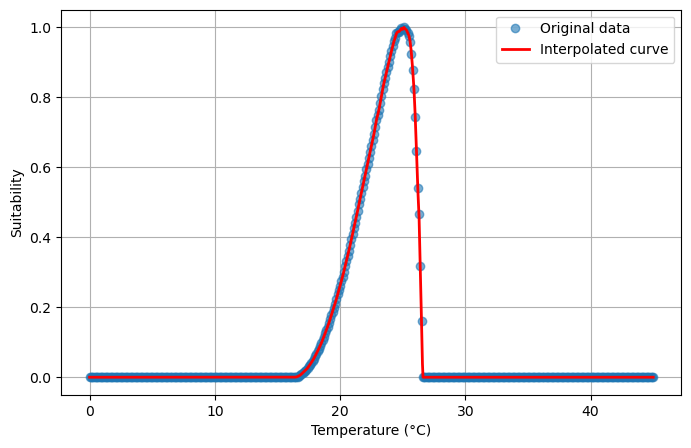

In [4]:
# Check the interpolation function
temps = np.linspace(suitability["temp"].min(), suitability["temp"].max(), 1000)

plt.figure(figsize = (8,5))
plt.plot(suitability["temp"], suitability["scaled_lowerCI"], 'o', label="Original data", alpha=0.6)
plt.plot(temps, suit_func(temps), '-', label = "Interpolated curve", color='red', linewidth=2)
plt.xlabel("Temperature (°C)")
plt.ylabel("Suitability")
plt.legend()
plt.grid(True)
plt.show()

Below are some functions to calculate thermal suitability and to test whether mean changes are significant. The first function, effective_sample_size, calculates the effective sample size to account for non-independence between serially correlated data points. The second function, get_suitability, calculates the number of days that S(T) > 0.001 for each grid cell in each year, as well as some summary statistics for significance testing.

In [5]:
# function for calculating effective sample size, copied section 3.4 from the guidebook
def effective_sample_size(data):
    ntime = len(data.time)
    # times not including the final timestep
    times = data.time.isel(time = slice(0, ntime - 1))
    # data not including the first timestep
    data_lag = data.isel(time = slice(1, ntime))
    # match up time values, otherwise the xr.corr function won't return the correct output
    data_lag = data_lag.assign_coords(time = times)
    
    # calculate correlation
    autocor = xr.corr(data.sel(time = times),
                      data_lag,
                      dim = 'time')
    
    neff = ntime * (1 - autocor) / (1 + autocor)
    
    return neff

In [6]:
def get_suitability(data, thres = 0.001):
    
    # Find suitability in each year
    S = xr.apply_ufunc(
        suit_func,
        # data.temperature,
        data.tas,
        dask="parallelized",
        output_dtypes=[float])
    
    # Get effective sample size for each period, for significance testing later on
    neff = effective_sample_size(S)

    # Count the number of days where S > thres in each year

    # S = S.where(~np.isnan(data.temperature))
    S = S.where(~np.isnan(data.tas))
    
    suit_days = S > thres
    days_per_year = suit_days.groupby("time.year").sum(dim = "time")

    # Keep land mask
    # mask = data.temperature.isel(time=0).isnull()
    mask = data.tas.isel(time=0).isnull()
    days_per_year = days_per_year.where(~mask)
    
    # Summary statistics (mean and stdev) - inputs for ttest_ind_from_stats
    suit_days_mean = days_per_year.mean('year') # Calculate the mean # of days where S across the whole period
    suit_days_std = days_per_year.std('year') #Standard deviation
    
    ds_out = xr.Dataset({'mean': suit_days_mean, 
                         'std': suit_days_std, 
                         'neff': neff})
    
    return ds_out

## GCM data
Here we will use a publicly available downscaled gridded data from PCIC. PCIC used observations from NRCAN gridded data from 1950 - 2005 to perform BCCAQv2 downscaling.

In [7]:
# acquire downscaled data from PAVICS - same as section 4.4
url_pavics = "https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/catalog/datasets/"
url_downscaled = url_pavics + "simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/catalog.xml"
cat_sds = TDSCatalog(url_downscaled)

# open the downscaled gcm dataset and load the data
opendap_urls = [cat_sds.datasets[i].access_urls["OPENDAP"] for i in range(len(cat_sds.datasets))]
datasets_canesm_sds = list(filter(lambda x: 'CanESM' in x, opendap_urls))

datasets_canesm_sds

['https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r10i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r1i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r2i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r3i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp126_r4i1p2f1_gn_1950-2100.ncml',
 'https://pavics.ou

This time we will use CanESM5 ensemble member r1i1p2f1

In [8]:
ssp245_url = datasets_canesm_sds[11] #SSP2-4.5; ensemble member: r1i1p2f1
print(ssp245_url)
ssp245_all = xr.open_dataset(ssp245_url)[['tasmax','tasmin']]

https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/dodsC/datasets/simulations/bias_adjusted/cmip6/pcic/CanDCS-U6/day_BCCAQv2+ANUSPLIN300_CanESM5_historical+ssp245_r1i1p2f1_gn_1950-2100.ncml


In [9]:
# select spatial domain (all of Canada)
# lat_bnds = [41, 90]
# lon_bnds = [-143, -52]

# select spatial domain (Down to central Manitoba)
lat_bnds = [55, 90]
lon_bnds = [-143, -59]


# select spatial domain
ssp245 = ssp245_all.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

## Saving the climate data
Since the dataset is too large, we will subset the dataset by year and save each year as its own .nc file.

In [43]:
start_year = 1950
end_year = 1950

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Save as NetCDF file
    outfile = f"tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year.to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 1950...
Saved tas_day_CanESM5_ssp245_r1i1p2f1_1950.nc


In [ ]:
# select GCM data for historical and future periods
ssp2_hist1 = ssp245.sel(time = ssp245.time.dt.year.isin(range(1950, 1951)))
ssp2_hist2 = ssp245.sel(time = ssp245.time.dt.year.isin(range(1995, 2026)))
ssp2_future1 = ssp245.sel(time = ssp245.time.dt.year.isin(range(2030, 2061)))
ssp2_future2 = ssp245.sel(time = ssp245.time.dt.year.isin(range(2070, 2101)))

We need daily mean temperature. However, this dataset only contains the daily maximum and daily minimum temperatures. To get the daily mean temperature, we will take the average of the daily maximum and daily minimum. Since the dataset is too large, we will subset the dataset by year and compute the mean temperature.

In [11]:
start_year = 1980
end_year = 1980

# Loop through each year
for year in range(start_year, end_year + 1):
    print(f"Processing year {year}...")
    
    ds_year = ssp245.sel(time = ssp245.time.dt.year == year)

    # Calculate the mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'
    
    print(f"Finished processing year {year}. Now saving file...")
    # Save as NetCDF file
    outfile = f"tas_day_CanESM5_ssp245_r1i1p2f1_{year}.nc"
    ds_year['tas'].to_netcdf(outfile)

    print(f"Saved {outfile}")

Processing year 1980...
Saved tas_day_CanESM5_ssp245_r1i1p2f1_1980.nc


In [ ]:
ssp245 = ssp245_all
ds_year = ssp245.sel(time = ssp245.time.dt.year == 1950)

# Calculate the mean temperature
ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
ds_year.tas.attrs['units'] = 'DegC'

In [35]:
# Save as NetCDF file
outfile = f"tas_day_CanESM5_ssp245_r1i1p2f1_1950.nc"
ds_year.to_netcdf(outfile)

In [58]:
ds_year

<xarray.Dataset>
Dimensions:  (time: 365, lat: 510, lon: 1068)
Coordinates:
  * lon      (lon) float64 -141.0 -140.9 -140.8 -140.7 ... -52.21 -52.13 -52.04
  * lat      (lat) float64 41.04 41.12 41.21 41.29 ... 83.21 83.29 83.37 83.46
  * time     (time) object 1950-01-01 00:00:00 ... 1950-12-31 00:00:00
Data variables:
    tasmax   (time, lat, lon) float32 ...
    tasmin   (time, lat, lon) float32 ...
    tas      (time, lat, lon) float32 nan nan nan nan nan ... nan nan nan nan
Attributes: (12/54)
    institution:                Pacific Climate Impacts Consortium (PCIC), Vi...
    contact:                    Pacific Climate Impacts Consortium
    Conventions:                CF-1.7 CMIP-6.2
    domain:                     Canada
    creation_date:              2020-11-23T10:34:14PST
    frequency:                  day
    ...                         ...
    bias_adjustment_method_id:  BCCAQv2
    bias_adjustment_reference:  Alex J. Cannon, Stephen R. Sobie, and Trevor ...
    license_type:               permissive
    license:                    https://open.canada.ca/en/open-government-lic...
    terms_of_use:               Further terms of use at https://pacificclimat...
    attribution:                Citation information for this dataset can be ...

## Calculate daily mean temperature
Since the dataset is too large, we will subset the dataset by year and do the calculation, then combine the results

In [46]:
# Get the time range
years = sorted(set(ssp245.time.dt.year.values)) # 1950-2100
years = years[0:2]

# Create an empty list to store the yearly mean temperature dataset
yearly_ds = []

for yr in years:
    ds_year = ssp245.sel(time = ssp245.time.dt.year == yr)
    
    # Calculate the daily mean temperature
    ds_year['tas'] = (ds_year['tasmin'] + ds_year['tasmax'])/2
    ds_year.tas.attrs['units'] = 'DegC'

    # Append to list
    yearly_datasets.append(tas)

# Combine all years back along the time dimension
ssp245_tas = xr.concat(yearly_datasets, dim = 'time')

Error:DAP DATADDS packet is apparently too short


KeyboardInterrupt: 

In [10]:
ssp245_1980 = xr.open_mfdataset("tas_day_CanESM5_ssp245_r1i1p2f1_1980.nc")
ssp245_2025 = xr.open_mfdataset("tas_day_CanESM5_ssp245_r1i1p2f1_2025.nc")
ssp245_2060 = xr.open_mfdataset("tas_day_CanESM5_ssp245_r1i1p2f1_2060.nc")
ssp245_2100 = xr.open_mfdataset("tas_day_CanESM5_ssp245_r1i1p2f1_2100.nc")

In [11]:
# select spatial domain
lat_bnds = [59, 90]
lon_bnds = [-143, -59]

ssp245_1980 = ssp245_1980.sel(lat = slice(*lat_bnds), lon = slice(*lon_bnds))

In [17]:
#S(T) > 0.001
ssp245_1980_suit = get_suitability(ssp245_1980)
ssp245_2025_suit = get_suitability(ssp245_2025)
ssp245_2060_suit = get_suitability(ssp245_2060)
ssp245_2100_suit = get_suitability(ssp245_2100)

# S(T) > 0.5
ssp245_1980_suit_high = get_suitability(ssp245_1980, thres = 0.5)
ssp245_2025_suit_high = get_suitability(ssp245_2025, thres = 0.5)
ssp245_2060_suit_high = get_suitability(ssp245_2060, thres = 0.5)
ssp245_2100_suit_high = get_suitability(ssp245_2100, thres = 0.5)

/Users/lilianchanty/opt/anaconda3/envs/UTCDW/lib/python3.9/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/Users/lilianchanty/opt/anaconda3/envs/UTCDW/lib/python3.9/site-packages/xarray/core/indexing.py:1443: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  ret

In [18]:
ssp245_1980_suit

<xarray.Dataset>
Dimensions:  (lon: 1068, lat: 510)
Coordinates:
  * lon      (lon) float64 -141.0 -140.9 -140.8 -140.7 ... -52.21 -52.13 -52.04
  * lat      (lat) float64 41.04 41.12 41.21 41.29 ... 83.21 83.29 83.37 83.46
    time     object 1980-01-01 00:00:00
Data variables:
    mean     (lat, lon) float64 dask.array<chunksize=(510, 1068), meta=np.ndarray>
    std      (lat, lon) float64 dask.array<chunksize=(510, 1068), meta=np.ndarray>
    neff     (lat, lon) float64 dask.array<chunksize=(510, 1068), meta=np.ndarray>

### Mapping

#### 1980

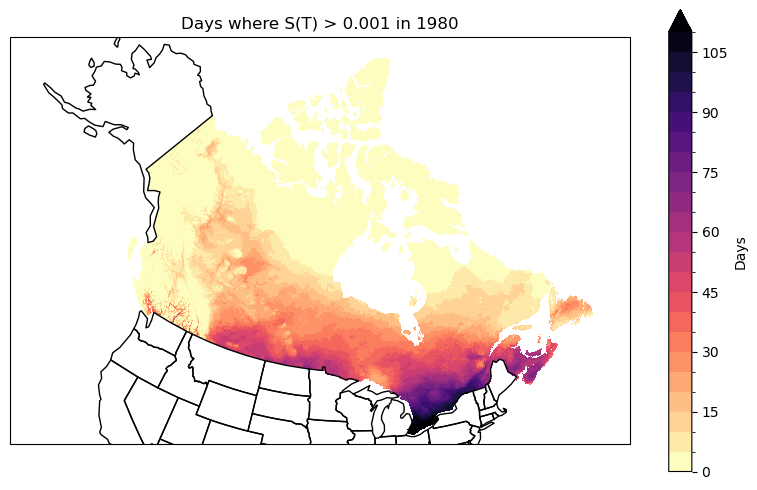

In [19]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_1980_suit["mean"].plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title("Days where S(T) > 0.001 in 1980")

#plt.savefig("figures/S_0.001_1980.png", dpi=300, bbox_inches="tight")

plt.show()

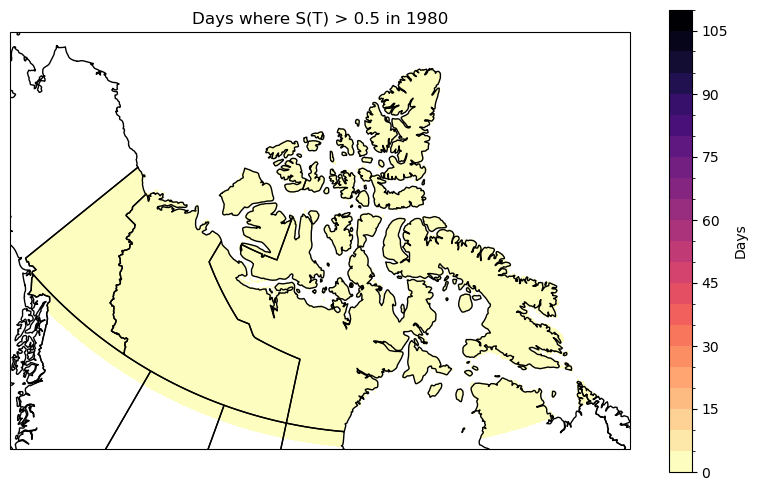

In [11]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_1980_suit_high["mean"].plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title("Days where S(T) > 0.5 in 1980")

plt.savefig("figures/S_0.5_1980.png", dpi=300, bbox_inches="tight")

plt.show()

#### 2025

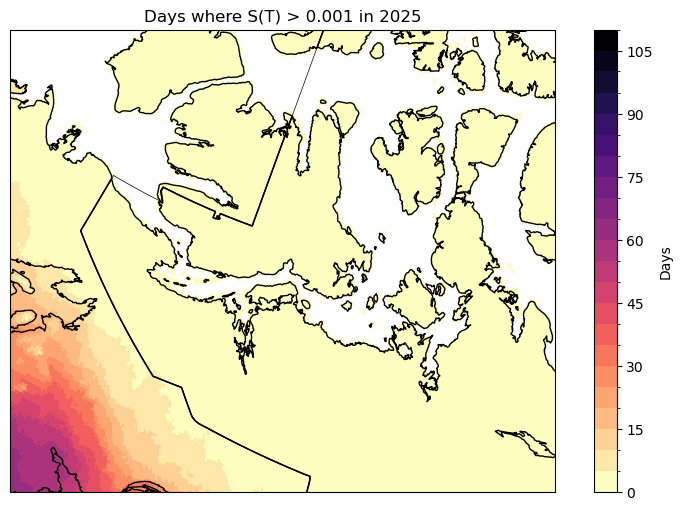

In [31]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())
ax.set_extent([-88, -120.6, 64.4, 74], ccrs.PlateCarree()) # Kitimeot region

# plot the data with 20 filled contours
ssp245_2025_suit["mean"].plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)
#ax.add_feature(cfeature.LAKES, zorder = 1)
province_boundaries = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none' # To avoid filling the provinces with color
    )
ax.add_feature(province_boundaries, edgecolor='black', linewidth=0.5)

# plot title
ax.set_title("Days where S(T) > 0.001 in 2025")

#plt.savefig("figures/S_0.001_2025.png", dpi=300, bbox_inches="tight")

plt.show()

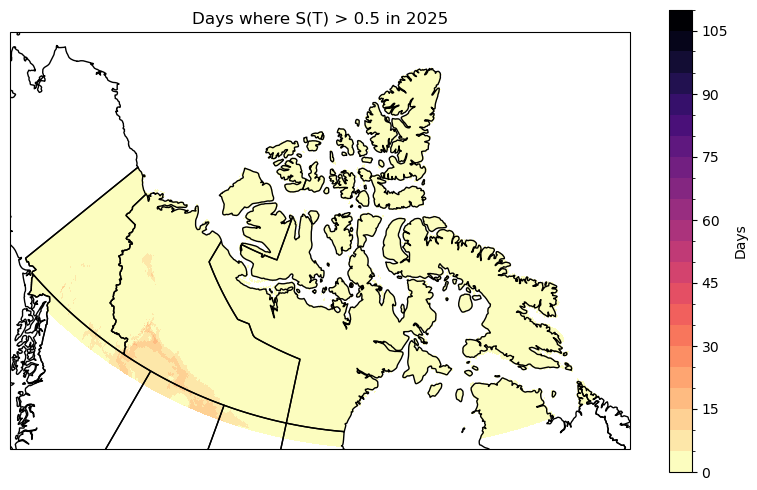

In [12]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_2025_suit_high["mean"].plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title("Days where S(T) > 0.5 in 2025")

plt.savefig("figures/S_0.5_2025.png", dpi=300, bbox_inches="tight")

plt.show()

#### 2060

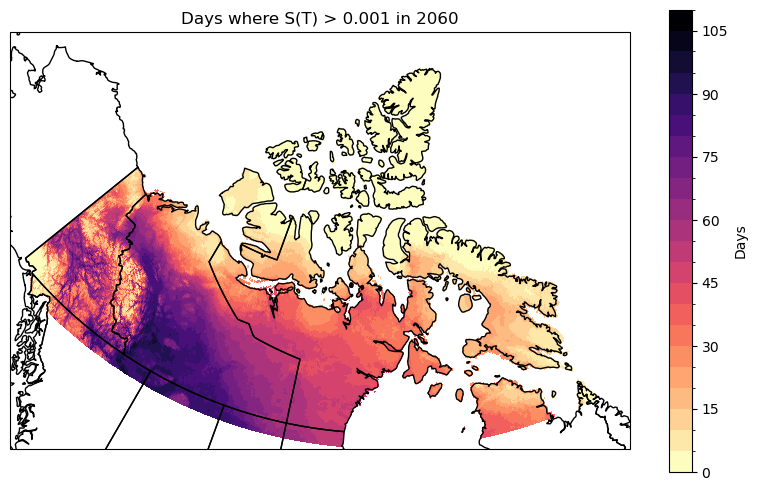

In [24]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_2060_suit["mean"].plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title("Days where S(T) > 0.001 in 2060")

plt.savefig("figures/S_0.001_2060.png", dpi=300, bbox_inches="tight")

plt.show()

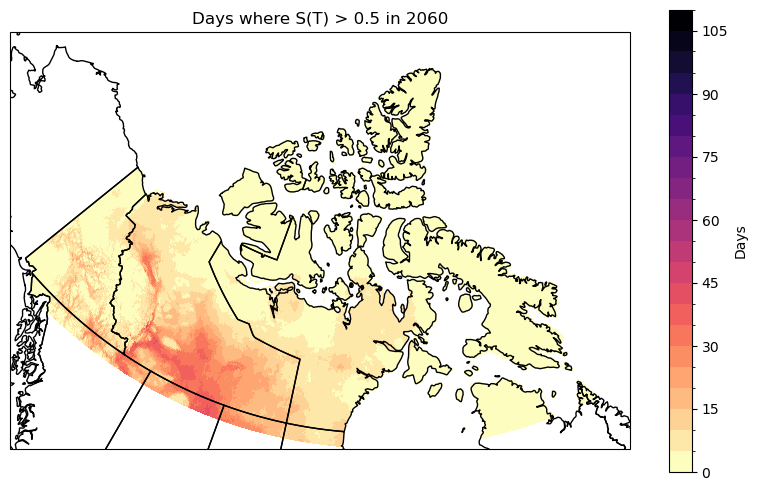

In [13]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_2060_suit_high["mean"].plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title("Days where S(T) > 0.5 in 2060")

plt.savefig("figures/S_0.5_2060.png", dpi=300, bbox_inches="tight")

plt.show()

#### 2100

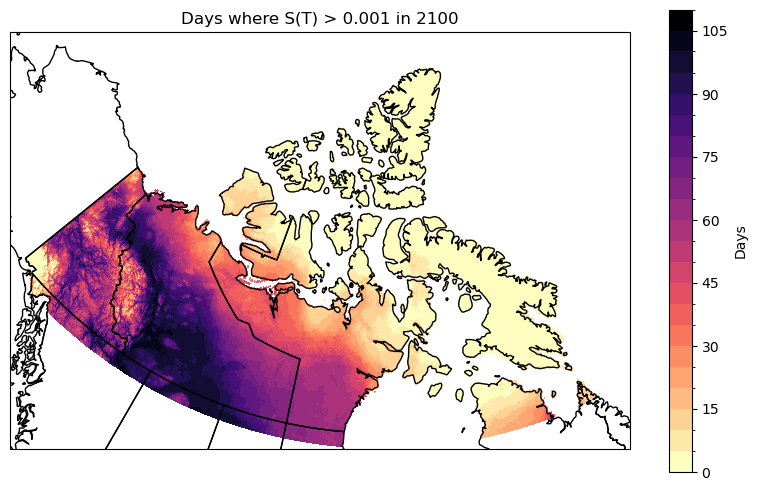

In [23]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_2100_suit["mean"].plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title("Days where S(T) > 0.001 in 2100")

plt.savefig("figures/S_0.001_2100.png", dpi=300, bbox_inches="tight")

plt.show()

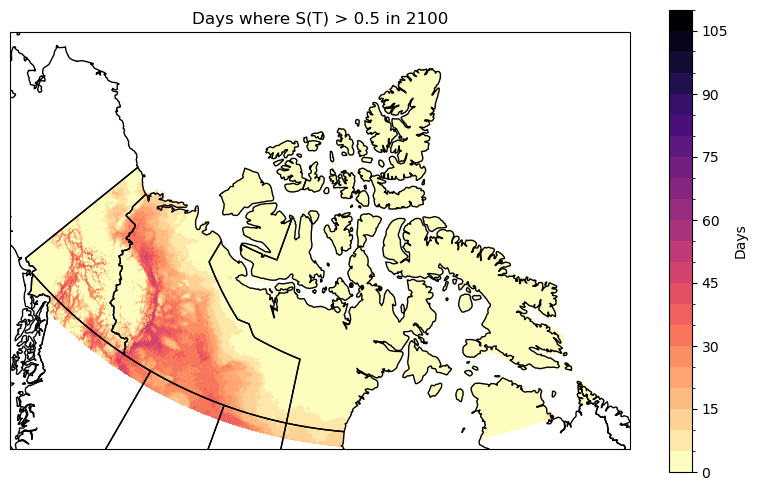

In [14]:
levels = np.arange(0, 115, 5)
# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
#ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())
#ax.set_extent([-85, -73.6, 41.6, 46.9], ccrs.PlateCarree())

# plot the data with 20 filled contours
ssp245_2100_suit_high["mean"].plot.pcolormesh(ax = ax, 
                                         transform = ccrs.PlateCarree(),
                                         levels = levels, 
                                         cmap = 'magma_r',
                                         cbar_kwargs = {'label': 'Days', 'orientation': 'vertical'}
                                        )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot title
ax.set_title("Days where S(T) > 0.5 in 2100")

plt.savefig("figures/S_0.5_2100.png", dpi=300, bbox_inches="tight")

plt.show()

## Temperature of a random day

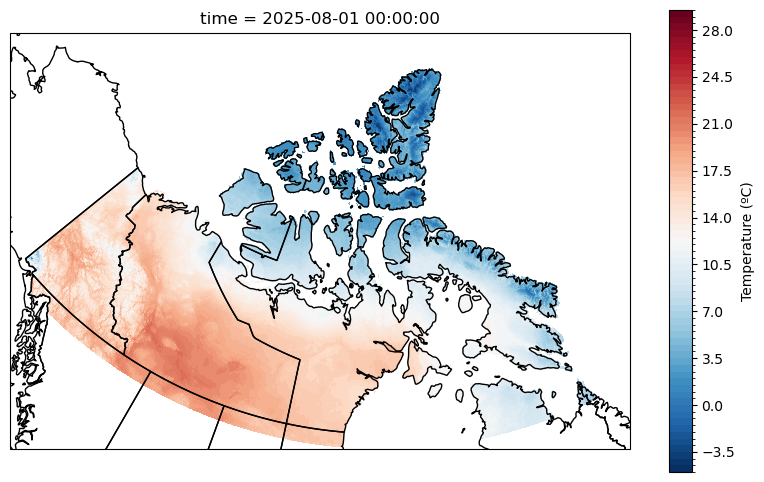

In [14]:
levels = np.arange(-5, 30, 0.5)

# set up axes with the 'PlateCarree' rectangular coordinate projection for plotting a map
fig, ax = plt.subplots(subplot_kw = dict(projection = ccrs.AzimuthalEquidistant(central_longitude = -90, central_latitude = 90)),
                       figsize = (10, 6))

# Limit the map to -60 degrees latitude and below:
# ax.set_extent([-140, -60, 64, 90], ccrs.PlateCarree())


# select the temperature data for a particular day
sample_time = '2025-08-01'
temp_sample = ssp245_2025.tas.sel(time = sample_time) 



# plot the data
temp_sample[0].plot.pcolormesh(ax = ax, 
                                    transform = ccrs.PlateCarree(),
                                    levels = levels, 
                                    cmap = 'RdBu_r',
                                    cbar_kwargs = {'label': 'Temperature (ºC)', 
                                                 'orientation': 'vertical'}
                                   )

# add coastlines to the map so we can easily determine what is land and what is not
# ax.coastlines()

# add provincial borders and make sure they're plotted on top of the contour data
ax.add_feature(cfeature.STATES, zorder = 1)

# plot the location of Cambridge Bay and Kugluktuk as a dot
# lat_cbay = 69.1169
# lon_cbay = -105.0597
# ax.plot(lon_cbay, lat_cbay, marker = 'o', color = 'r', label = 'Cambridge Bay',
#         transform = ccrs.PlateCarree())

# lat_kug = 67.8252
# lon_kug = -115.0966
# ax.plot(lon_kug, lat_kug, marker = 'o', color = 'b', label = 'Kugluktuk',
#         transform=ccrs.PlateCarree())
# ax.legend()

# plot title
#ax.set_title("Days where S(T) > 0.001 in 2100")

plt.savefig("figures/temp.20250801.png", dpi=300, bbox_inches="tight")
plt.show()